# 03 — VIO pilot

**Question.** Can we replace the homography ground truth (see `02_calibration_demo.ipynb`) with a VIO-based pipeline that gives metric world coordinates without a per-camera, per-scene calibration?

**Pipeline.**

```
CamTrackAR (ARKit / VIO)  →  CameraKeyframes.CSV  (per-frame 6-DoF camera pose)
Video                     →  YOLOv8                →  foot_pixels.csv   (per-frame foot (u,v))
                                                          │
                                CameraKeyframes + foot_pixels
                                                          ▼
                                            vio/pixel_to_world.py
                                                  (ray-cast to floor y=0)
                                                          │
                                                          ▼
                                            world_trajectory.csv  (metres, world frame)
                                                          │
                                                          ▼
                                            Trajectron++ inference
                                            (downsample to dt=0.4 s)
```

**What this notebook covers.**

1. **Validation — three tape-measure walks (1 m / 5 m / 10 m).** Compares the straight-line camera displacement reported by VIO against a tape-measure ground truth.
2. **Field clip 1 — static phone, one person walking ~44 s** inside a 10 m × 20 m volleyball court. End-to-end: YOLO → ray-cast → world trajectory → Trajectron++ sample predictions on a sliding window.
3. **Field clip 2 — same court, second take.** Same camera position, same volume; used as a repeatability check.
4. **ETH base vs. UAV fine-tune** — ADE / FDE / best-of-20 comparison of `eth_100ep` against `v8_persp` on the same VIO trajectories.
5. **Findings & next steps.**

> **Note on this revision.** An earlier version of `vio/pixel_to_world.py` mis-interpreted the `FOV` column of `CameraKeyframes.CSV` (radians vs. degrees), which compressed the apparent scene in Field 1 and inflated it 4-5× in Field 2. After the fix both clips correctly fall inside the volleyball court footprint (depth ≤ 20 m). All numbers in this notebook were re-generated with the corrected intrinsics.

Everything below is reproducible from the CSVs sitting under `data/vio/`. The actual YOLO / ray-cast / predict commands are in the module docstrings (`vio/run_yolo_foot.py`, `vio/pixel_to_world.py`, `vio/predict_with_trajectron.py`); this notebook just loads and visualises the cached outputs.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

from vio.pixel_to_world   import run as run_pixel_to_world
from vio.validate_camera_walk import summarise as walk_summary
from vio.analyze_field    import summarise as field_summary, plot as field_plot
from vio.predict_with_trajectron import run as run_predict
from vio.plot_predictions import plot_panels

DATA_DIR = REPO_ROOT / 'data' / 'vio'
RAW_VIDEO_DIR = Path('~/Desktop/uav_perception/vio_raw_video').expanduser()
print('Raw videos dir:', RAW_VIDEO_DIR, '— exists:', RAW_VIDEO_DIR.exists())
print('Processed data dir:', DATA_DIR, '— exists:', DATA_DIR.exists())

Raw videos dir: /Users/simayyalcin/Desktop/uav_perception/vio_raw_video — exists: True
Processed data dir: /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/vio — exists: True


---
## 1. Validation: tape-measure walks

I recorded three short clips (1 m / 5 m / 10 m). In each clip I held the phone in my hand, started CamTrackAR, walked **straight forward** a measured distance, and stopped. I did **not** drop ARKit anchors at the endpoints — instead, the phone's own VIO pose between the first and last keyframe is the measurement.

The cell below loads each `CameraKeyframes.CSV`, computes:
- **3D displacement** = ‖ `pos_end − pos_start` ‖
- **XZ displacement** = horizontal component (drops the vertical wobble caused by walking)
- **Path length** = sum of per-frame steps (an upper bound — any sway/correction inflates it)

and compares the XZ displacement to the tape-measure ground truth.

In [2]:
VALIDATION_TESTS = [
    ("1 m walk",  RAW_VIDEO_DIR / '1meters_2026_05_18_1451540740'  / 'CameraKeyframes.CSV',  1.00),
    ("5 m walk",  RAW_VIDEO_DIR / '5meters_2026_05_18_1452443210'  / 'CameraKeyframes.CSV',  5.00),
    ("10 m walk", RAW_VIDEO_DIR / '10meters_2026_05_18_1453246860' / 'CameraKeyframes.CSV', 10.00),
]

rows = []
for label, path, expected in VALIDATION_TESTS:
    if not path.exists():
        print(f'{label}: SKIPPED (file not found: {path})')
        continue
    res = walk_summary(path, expected=expected)
    rows.append({
        'test': label,
        'expected_m':       res['expected_m'],
        'XZ displacement (m)':  res['displacement_xz_m'],
        '3D displacement (m)':  res['displacement_3d_m'],
        'path length XZ (m)':   res['path_length_xz_m'],
        'error vs expected (m)': res['error_xz_m'],
        'error (%)':            res['error_xz_pct'],
        'duration (s)':         res['duration_s'],
        'keyframes':            res['n_frames'],
    })

if rows:
    summary = pd.DataFrame(rows)
    display(summary.style.format({
        'expected_m':           '{:.3f}',
        'XZ displacement (m)':  '{:.3f}',
        '3D displacement (m)':  '{:.3f}',
        'path length XZ (m)':   '{:.3f}',
        'error vs expected (m)': '{:+.3f}',
        'error (%)':            '{:+.2f}',
        'duration (s)':         '{:.2f}',
    }))
else:
    print('No validation files found.')

,test,expected_m,XZ displacement (m),3D displacement (m),path length XZ (m),error vs expected (m),error (%),duration (s),keyframes
0,1 m walk,1.000,1.097,1.097,1.490,+0.097,+9.68,16.33,981
1,5 m walk,5.000,4.963,4.963,5.115,-0.037,-0.75,15.77,947
2,10 m walk,10.000,9.861,9.861,10.024,-0.139,-1.39,25.65,1540


### What this tells us

* Sub-percent error at 5 m and 10 m (XZ displacement vs. tape) confirms ARKit's metric scale is solid for **walking-distance** measurements.
* At 1 m the error is bigger in percent terms because (a) body sway is comparable to the walked distance, and (b) the very first ARKit pose can drift a few cm while the SLAM map is still being built.
* **Path length** is always ≥ **displacement** — the extra cm/m is real human meandering, not VIO noise.

**Conclusion.** VIO gives us a metric coordinate frame good enough for ground truth in the trajectory experiments, with no calibration step per scene.

---
## 2. Field clip 1 — static phone, person walking ~44 s

The phone sat on a table; one person walked around the room for the recording. We:

1. Copied the CamTrackAR exports into `data/vio/field_001/`.
2. Ran YOLOv8s on the `.mp4` (`vio/run_yolo_foot.py`) → `foot_pixels.csv` (one row per detected frame, `(u, v)` = foot point).
3. Ran `vio/pixel_to_world.py` → `world_trajectory.csv` (foot point ray-cast onto the ARKit floor plane).
4. Ran `vio/predict_with_trajectron.py` with the v8 fine-tuned model → `predictions_v8.npz` (20 samples × 12 future steps per window).

In [3]:
FIELD1 = DATA_DIR / 'field_001'
TRAJ1 = FIELD1 / 'world_trajectory.csv'
PRED1 = FIELD1 / 'predictions_v8.npz'
PRED1_ETH = FIELD1 / 'predictions_eth100.npz'
TRAJ1_PNG = FIELD1 / 'trajectory_plot.png'

MODEL_ETH_DIR = Path.home() / 'Trajectron-plus-plus/experiments/pedestrians/models/models_08_Mar_2026_23_54_27_eth_100ep'
MODEL_V8_DIR = Path.home() / 'Trajectron-plus-plus/experiments/pedestrians/models/models_10_Mar_2026_00_42_50_uav_ft_v8_persp'

print('Field 1 directory contents:')
for f in sorted(FIELD1.iterdir()):
    print(f'  {f.name:<32}  {f.stat().st_size/1024:>8.1f} KB')

traj1 = pd.read_csv(TRAJ1)
sum1 = field_summary(traj1, smoothed_window=31)
print(f"\nDetections: {sum1['n_frames']} over {sum1['duration_s']:.1f} s")
print(f"Person area: X in [{sum1['x_min']:+.2f}, {sum1['x_max']:+.2f}] m, "
      f"Z in [{sum1['z_min']:+.2f}, {sum1['z_max']:+.2f}] m (depth ~{sum1['z_max']-sum1['z_min']:.1f} m)")
print(f"Camera at  ({sum1['cam_pos_x_mean']:+.3f}, {sum1['cam_pos_y_mean']:+.3f}, {sum1['cam_pos_z_mean']:+.3f}) m   "
      f"(motion std: X {sum1['cam_pos_x_std']*100:.1f} cm, Z {sum1['cam_pos_z_std']*100:.1f} cm)")
print(f"Mean speed (median-smoothed path): {sum1['mean_speed_smoothed_m_s']:.2f} m/s")


Field 1 directory contents:
  CameraKeyframes.CSV                  446.9 KB
  foot_pixels.csv                      164.1 KB
  overlay.mp4                       313397.0 KB
  overlay_from_csv.mp4              316499.1 KB
  predictions_eth100.npz               160.2 KB
  predictions_plot_eth100.png          321.2 KB
  predictions_plot_v8.png              321.5 KB
  predictions_v8.npz                   158.3 KB
  trajectory_plot.png                  108.4 KB
  world_trajectory.csv                 324.1 KB

Detections: 2502 over 44.1 s
Person area: X in [-2.20, +7.46] m, Z in [-16.80, -1.43] m (depth ~15.4 m)
Camera at  (-0.014, +1.370, +0.010) m   (motion std: X 1.4 cm, Z 0.6 cm)
Mean speed (median-smoothed path): 1.00 m/s


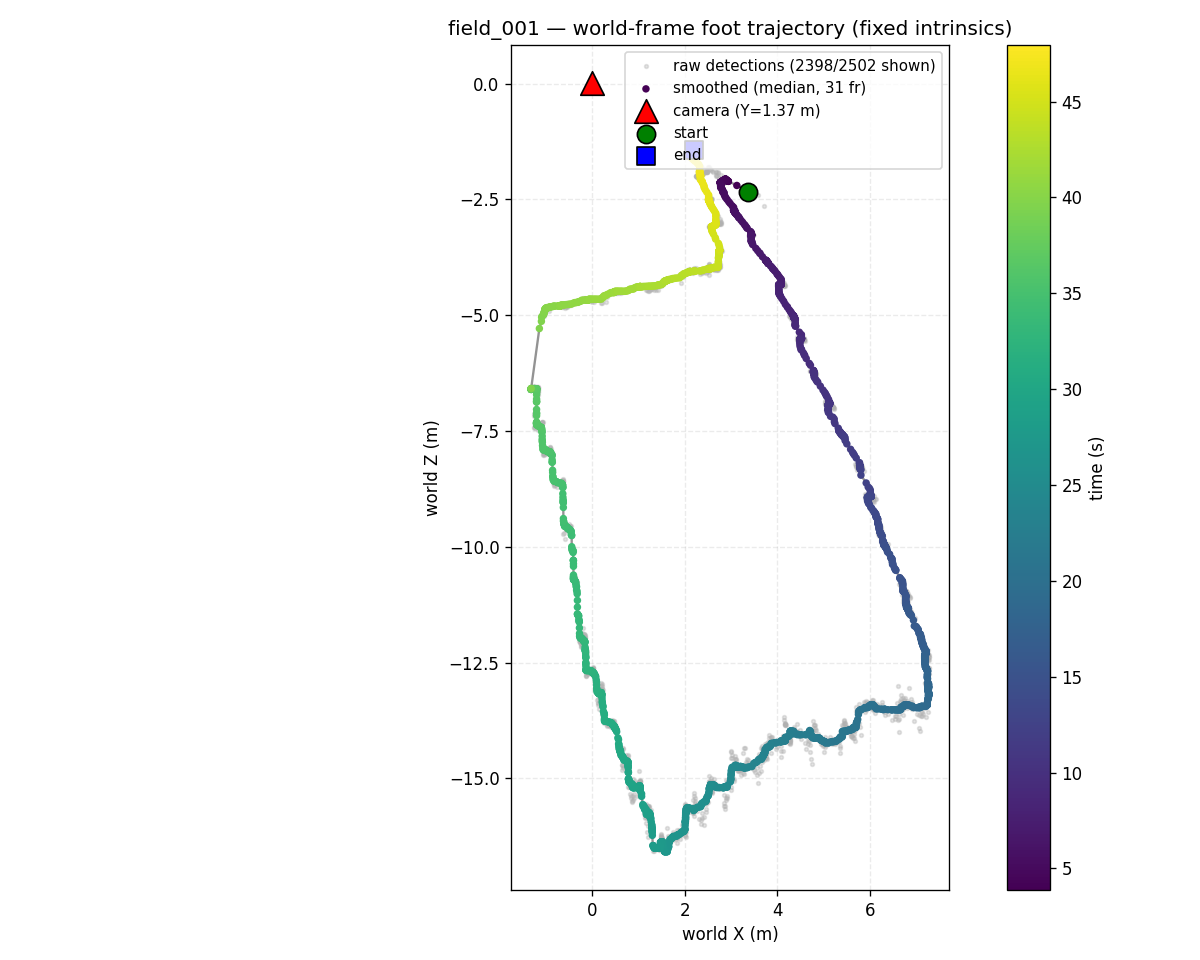

In [4]:
# Clean top-down trajectory figure
if TRAJ1_PNG.exists():
    display(Image(filename=str(TRAJ1_PNG)))
else:
    field_plot(traj1, sum1, TRAJ1_PNG, 'Field 1 trajectory (cleaned visualization)', smoothed_window=31)
    display(Image(filename=str(TRAJ1_PNG)))


### Trajectron++ predictions on Field 1

The world trajectory is at ~60 fps. The model was trained at `dt = 0.4 s` (so 2.5 fps), so we linearly interpolate the trajectory onto that grid before running inference. For every valid window (8 history + 12 future timesteps = 3.2 s + 4.8 s) we draw 20 samples from the model.

Numbers below are computed against the VIO ground truth on the same clip; they're not benchmarked vs. ETH/UCY because this is just a sanity check that the VIO output is in a form the model can consume.

In [5]:
def _npz_metrics(npz):
    if 'ade' in npz.files:
        return float(npz['ade']), float(npz['fde']), float(npz['best_ade'])
    m = npz['samples'].mean(axis=1)
    gt = npz['future_gt']
    ade = float(np.linalg.norm(m - gt, axis=-1).mean())
    fde = float(np.linalg.norm(m[:, -1] - gt[:, -1], axis=-1).mean())
    best = float(np.linalg.norm(npz['samples'] - gt[:, None], axis=-1).mean(axis=-1).min(axis=-1).mean())
    return ade, fde, best

pred1 = np.load(PRED1)
pred1_eth = np.load(PRED1_ETH)
print(f"Field 1 — windows: {pred1['history'].shape[0]}  (H={pred1['history'].shape[1]}, F={pred1['future_gt'].shape[1]}, S={pred1['samples'].shape[1]})")

ade, fde, best_ade = _npz_metrics(pred1)
ade_e, fde_e, best_e = _npz_metrics(pred1_eth)
print("\n--- UAV fine-tuned v8 (ckpt 45) ---")
print(f"ADE (mean): {ade:.3f} m   FDE: {fde:.3f} m   best-of-20 ADE: {best_ade:.3f} m")
print("--- ETH base model (100 epochs, ckpt 100) ---")
print(f"ADE (mean): {ade_e:.3f} m   FDE: {fde_e:.3f} m   best-of-20 ADE: {best_e:.3f} m")


Field 1 — windows: 92  (H=8, F=12, S=20)

--- UAV fine-tuned v8 (ckpt 45) ---
ADE (mean): 2.122 m   FDE: 3.704 m   best-of-20 ADE: 1.551 m
--- ETH base model (100 epochs, ckpt 100) ---
ADE (mean): 2.239 m   FDE: 4.029 m   best-of-20 ADE: 1.462 m


**Prediction panels** (history: black, GT future: red, 20 stochastic samples: light blue, sample mean: dark blue). Left: **UAV v8 fine-tune**. Right: **ETH 100-epoch base model**.

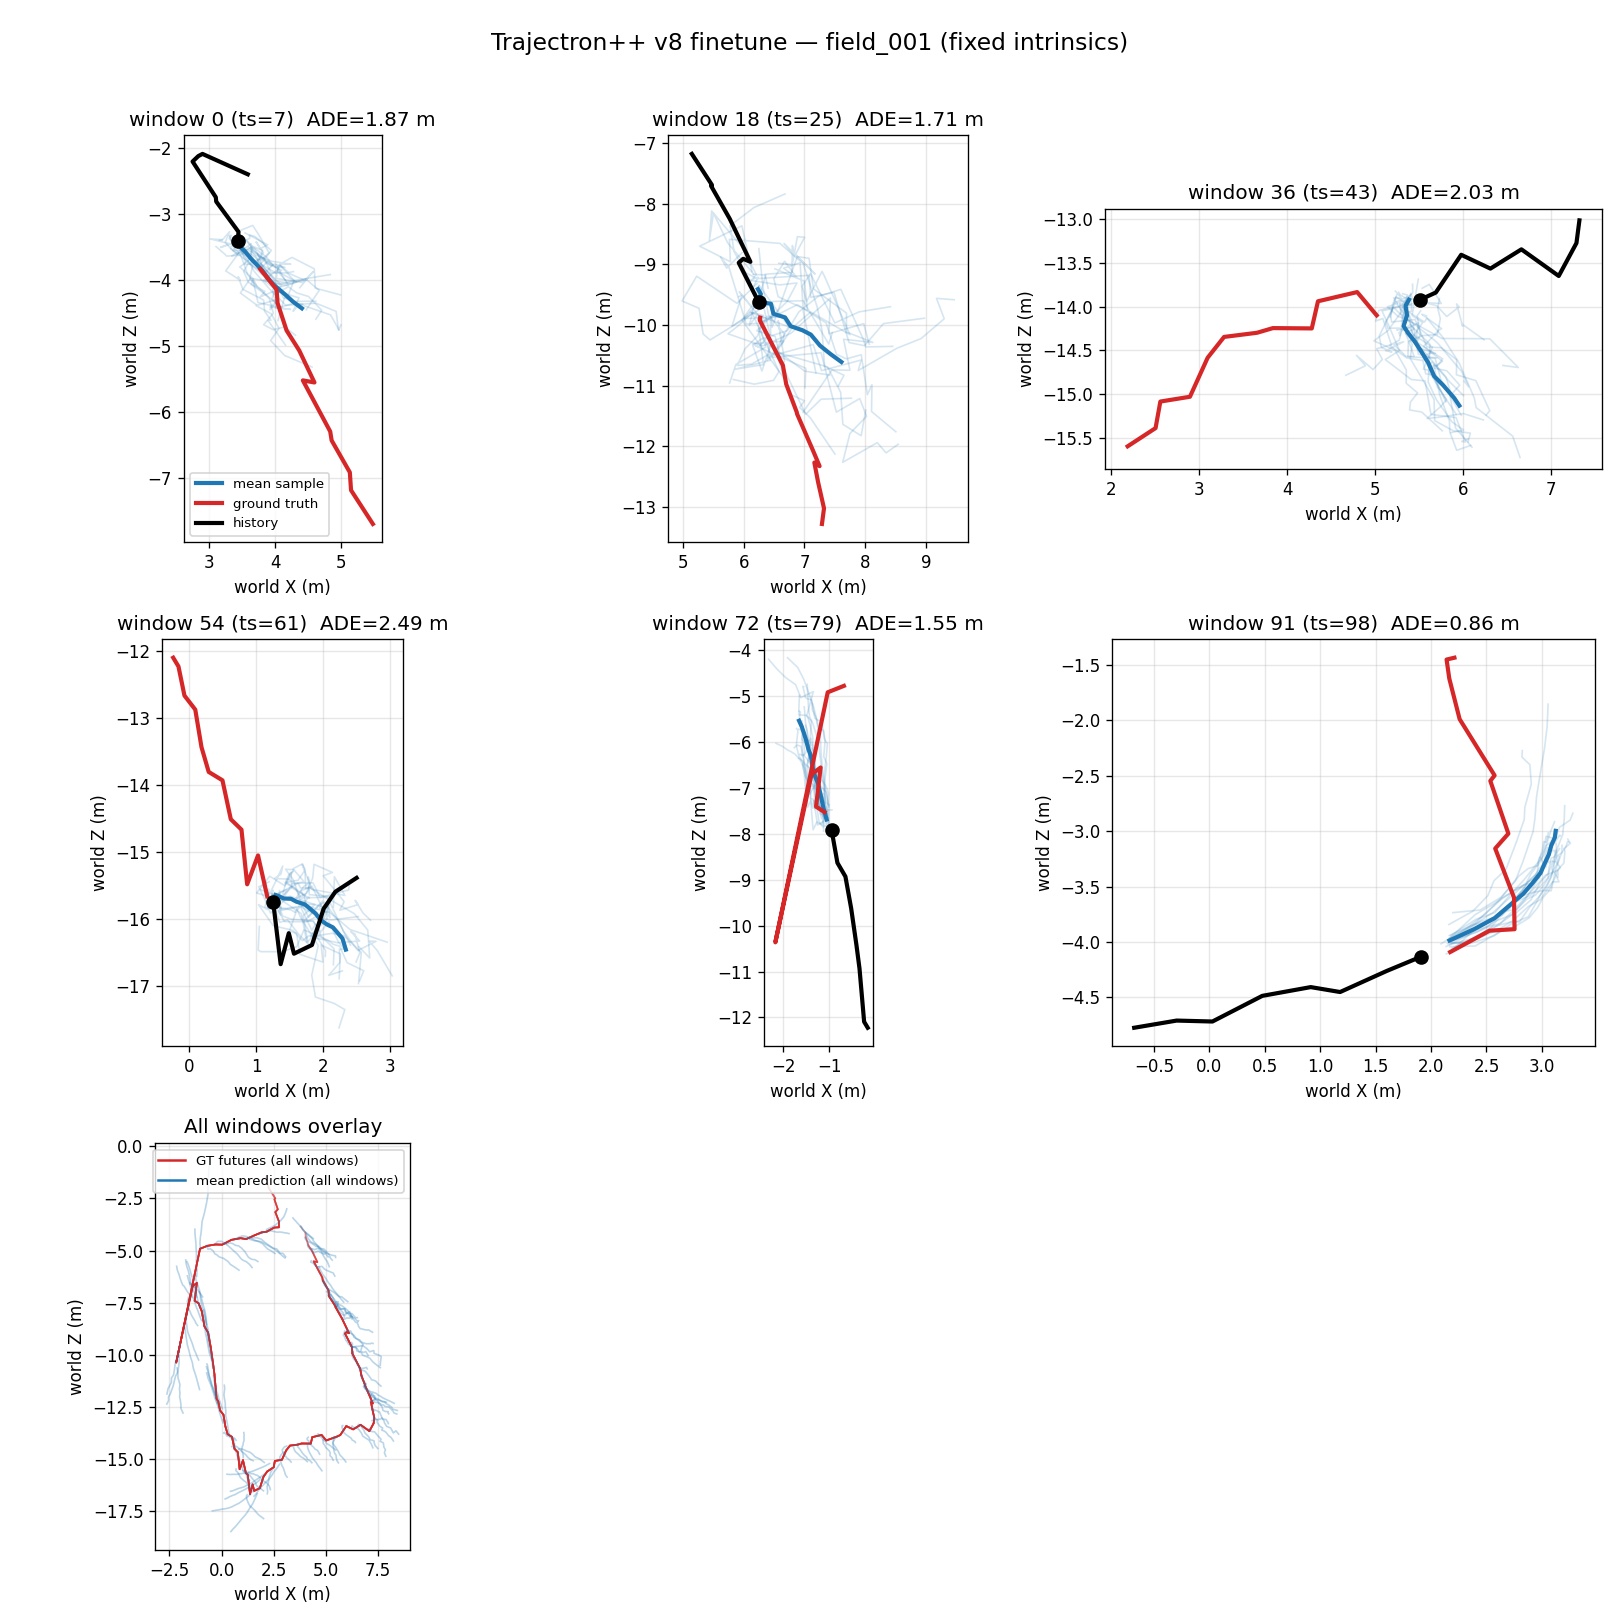

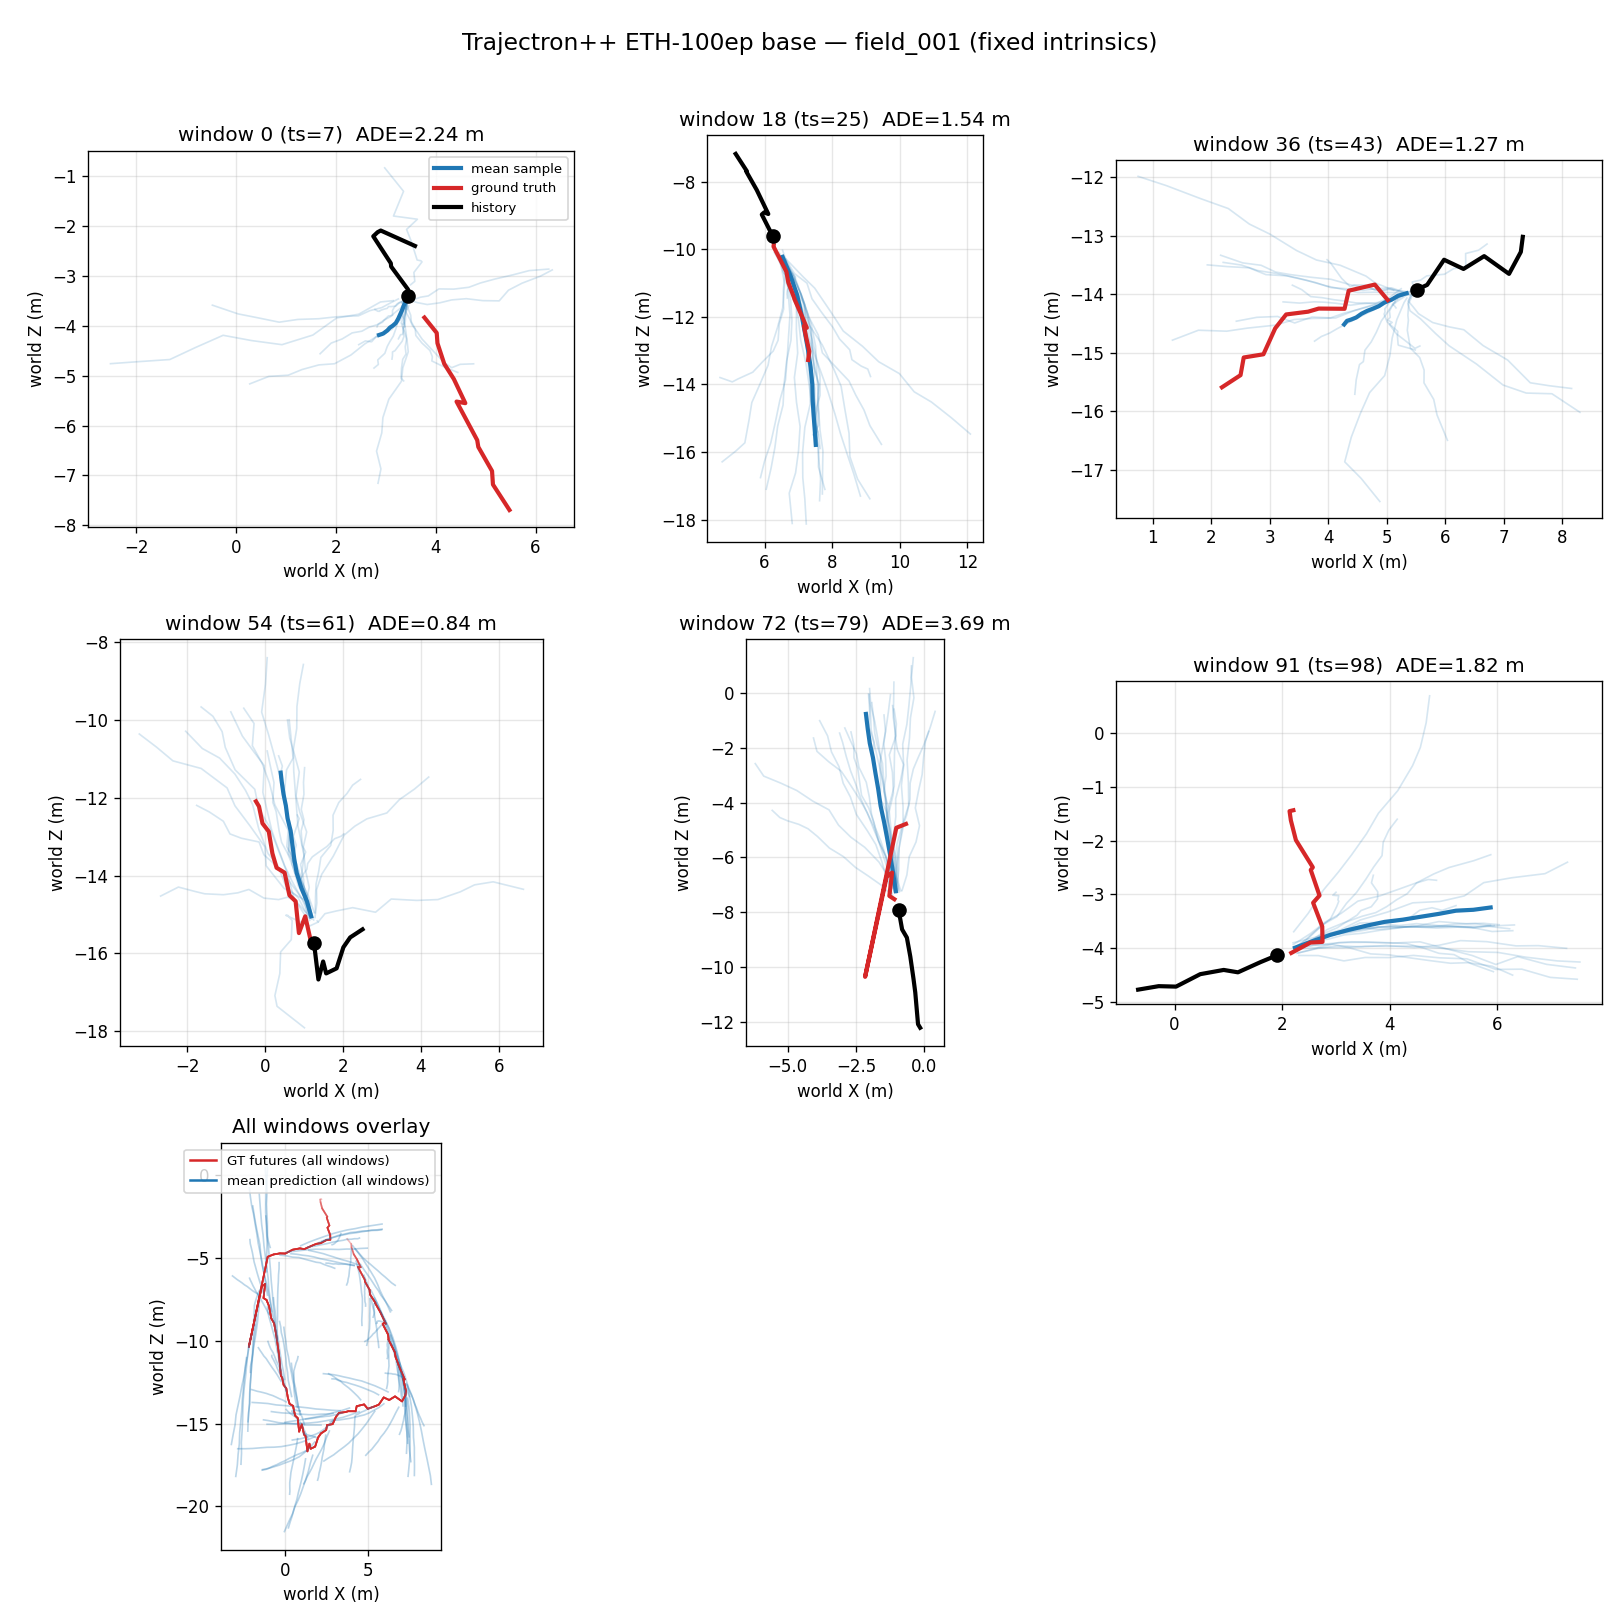

In [6]:
from IPython.display import Image as IPImage, display as IPdisplay
IPdisplay(IPImage(filename=str(FIELD1 / 'predictions_plot_v8.png')))
IPdisplay(IPImage(filename=str(FIELD1 / 'predictions_plot_eth100.png')))


---
### A quick word on ray-casting (so the geometry plots make sense)

`vio/pixel_to_world.py` turns each foot pixel `(u, v)` into a metric `(x, z)` on the floor as follows:

1. **Camera ray in camera coordinates.** Using a pinhole model with `(fx, fy, cx, cy)` — taken from CamTrackAR's `LensZoom` column (focal length in pixels, no unit ambiguity) — we form a ray direction in the camera frame:

   $$\mathbf{d}_{\text{cam}} = \big((u - c_x)/f_x,\; -(v - c_y)/f_y,\; -1\big)^\top$$

   ARKit's camera looks down its `-Z` axis with `+Y` up, so we negate `v` to align pixel-down with camera-down.

2. **Rotate into the world frame** using the per-frame ARKit quaternion $(q_x, q_y, q_z, q_w)$:

   $$\mathbf{d}_{\text{world}} = R(\mathbf{q})\,\mathbf{d}_{\text{cam}}$$

3. **Intersect with the floor** $Y = 0$ (the plane calibrated by CamTrackAR's "Set Floor" feature). Given camera position $\mathbf{p}_{\text{cam}}$:

   $$t = \frac{0 - p_{\text{cam},y}}{d_{\text{world},y}}, \qquad \mathbf{p}_{\text{floor}} = \mathbf{p}_{\text{cam}} + t\,\mathbf{d}_{\text{world}}$$

   The result $(p_{\text{floor},x},\; p_{\text{floor},z})$ is the metric position fed to Trajectron++.

**Sensitivity to pixel noise.** For a target at depth $d$, a pixel error $\Delta v$ produces a world-position error of roughly $\Delta s \approx d \cdot \Delta v / f_y$. The diagram below shows the same fixed pixel jitter (dashed orange rays) giving a small world error at a near target and a larger one at a far target — intrinsic to monocular floor ray-casting, and the reason we apply a short rolling-median to the world trajectory before forecasting.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.set_facecolor("#fafafa")

# Ground plane
ground_y = 0.0
ax.axhline(ground_y, color="#444", lw=2)
ax.fill_between([-0.5, 10.0], -0.45, ground_y, color="#dfe9d7", alpha=0.65)

# Camera
cx, cy = 0.0, 1.35
ax.plot(cx, cy, "o", ms=14, color="#d62828", label="camera (~1.35 m)")
ax.text(cx - 0.1, cy + 0.14, "camera", fontsize=10)


def draw_target(x, label, err_span, color="#1f77b4"):
    # True foot point on floor
    ax.plot(x, ground_y, "s", ms=9, color=color)

    # Nominal ray
    ax.plot([cx, x], [cy, ground_y], "-", lw=2.2, color="#1d3557")

    # Perturbed rays (pixel noise -> world uncertainty)
    ax.plot([cx, x - err_span], [cy, ground_y], "--", lw=1.3, color="#ff7f0e", alpha=0.85)
    ax.plot([cx, x + err_span], [cy, ground_y], "--", lw=1.3, color="#ff7f0e", alpha=0.85)

    # Error interval on floor
    ax.annotate(
        "",
        xy=(x + err_span, ground_y),
        xytext=(x - err_span, ground_y),
        arrowprops=dict(arrowstyle="<->", color="#d62828", lw=1.6),
    )
    ax.text(x, -0.27, label, ha="center", fontsize=9)


# Same pixel uncertainty, different depth
draw_target(2.3, "near target\nsmall meter error", err_span=0.12)
draw_target(8.0, "far target\nlarge meter error", err_span=0.50)

ax.set_xlim(-0.4, 10.2)
ax.set_ylim(-0.5, 2.2)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("horizontal distance (symbolic, m)")
ax.set_ylabel("height (m)")
ax.set_title("Ray-casting geometry: same pixel jitter -> larger world error at larger depth", fontsize=11)
ax.legend(loc="upper left")
ax.grid(alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()


/var/folders/qk/fhmvz1wd1s719d139j5224300000gn/T/ipykernel_51458/499074802.py:52: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


### Field 1 quick interpretation

- **Camera is truly static** (X / Z std only ~1-2 cm), so all motion you see in the trajectory plot is the person, not VIO drift.
- **Ray-cast geometry is consistent with the court:** the person stays inside a ~10 m × 16 m footprint (court is 10 m × 20 m), all distances below ~17 m. This matches what was recorded.
- **Model comparison:** UAV fine-tuned v8 and the ETH-100ep base model are within ~0.1 m of each other in ADE on this clip; ETH wins slightly on best-of-20 ADE. The gap is small because the person's motion is simple linear walking, which both models handle similarly.

---
## 3. Field clip 2 — same court, second take (repeatability check)

Same camera position, same 10 m × 20 m volleyball court, same single person walking. This clip exists only to verify that the pipeline gives **consistent metric geometry on a separate recording**, not to test a different setting.

Same pre-processing as Field 1: a 31-frame (≈ 0.5 s at 60 fps) rolling-median on `(world_x, world_z)` to reject per-frame ray-cast outliers, then resample to the model's `dt = 0.4 s`.

In [8]:
FIELD2 = DATA_DIR / 'field_002'
TRAJ2 = FIELD2 / 'world_trajectory.csv'
PRED2 = FIELD2 / 'predictions_v8.npz'
PRED2_ETH = FIELD2 / 'predictions_eth100.npz'
TRAJ2_PNG = FIELD2 / 'trajectory_plot.png'

print('Field 2 directory contents:')
for f in sorted(FIELD2.iterdir()):
    print(f'  {f.name:<32}  {f.stat().st_size/1024:>8.1f} KB')

traj2 = pd.read_csv(TRAJ2)
sum2 = field_summary(traj2, smoothed_window=31)

print(f"\nDetections: {sum2['n_frames']} over {sum2['duration_s']:.1f} s")
print(f"Person area: X in [{sum2['x_min']:+.2f}, {sum2['x_max']:+.2f}] m, "
      f"Z in [{sum2['z_min']:+.2f}, {sum2['z_max']:+.2f}] m (depth ~{sum2['z_max']-sum2['z_min']:.1f} m)")
print(f"Camera at  ({sum2['cam_pos_x_mean']:+.3f}, {sum2['cam_pos_y_mean']:+.3f}, {sum2['cam_pos_z_mean']:+.3f}) m   "
      f"(motion std: X {sum2['cam_pos_x_std']*100:.1f} cm, Z {sum2['cam_pos_z_std']*100:.1f} cm)")
print(f"\nTotal walked (raw):              {sum2['total_walked_m']:.1f} m  "
      f"(~{sum2['mean_speed_m_s']:.1f} m/s — inflated by per-frame ray-cast jitter)")
print(f"Total walked (median 31 frames): {sum2['total_walked_smoothed_m']:.1f} m  "
      f"(~{sum2['mean_speed_smoothed_m_s']:.1f} m/s — normal walking pace)")


Field 2 directory contents:
  CameraKeyframes.CSV                  534.5 KB
  foot_pixels.csv                      214.7 KB
  overlay_from_csv.mp4              382082.3 KB
  predictions_eth100.npz               201.1 KB
  predictions_plot_eth100.png          318.3 KB
  predictions_plot_v8.png              312.6 KB
  predictions_v8.npz                   199.7 KB
  trajectory_plot.png                  120.5 KB
  world_trajectory.csv                 421.9 KB

Detections: 3263 over 54.4 s
Person area: X in [-5.61, +3.39] m, Z in [-18.17, -2.36] m (depth ~15.8 m)
Camera at  (-0.028, +1.387, +0.035) m   (motion std: X 2.0 cm, Z 1.7 cm)

Total walked (raw):              221.7 m  (~4.1 m/s — inflated by per-frame ray-cast jitter)
Total walked (median 31 frames): 69.2 m  (~1.3 m/s — normal walking pace)


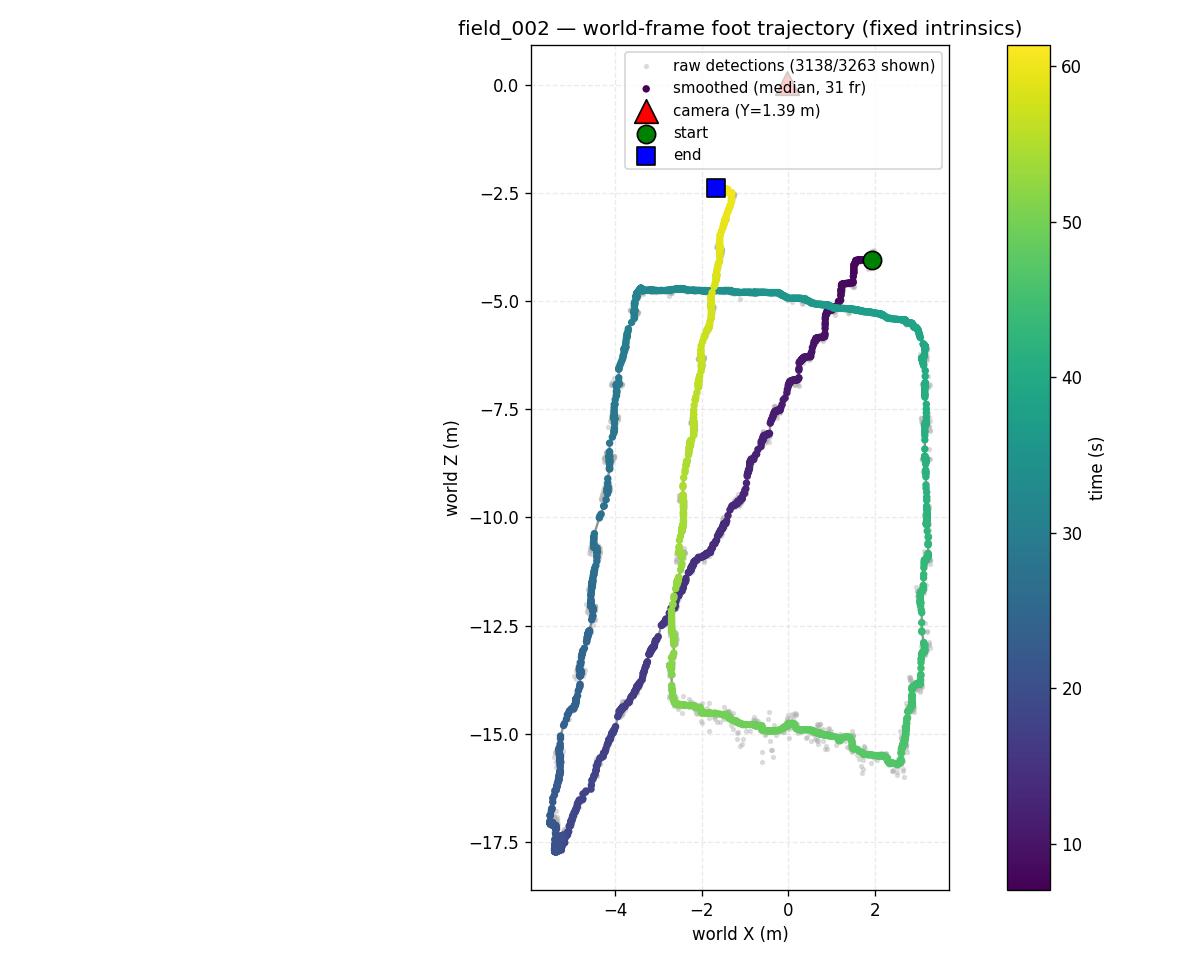

In [9]:
# Field 2 trajectory figure (raw + smoothed)
if TRAJ2_PNG.exists():
    display(Image(filename=str(TRAJ2_PNG)))
else:
    field_plot(
        traj2,
        sum2,
        TRAJ2_PNG,
        title='Field 2 trajectory — raw detections + 31-frame median',
        smoothed_window=31,
        show_raw=True,
    )
    display(Image(filename=str(TRAJ2_PNG)))


### Trajectron++ predictions on Field 2

Same processing pipeline as Field 1: 31-frame rolling median → resample to `dt = 0.4 s` → 8 history / 12 future window, 20 stochastic samples per window. Both models are evaluated below.

Field 2 — windows: 117  (H=8, F=12, S=20)

--- UAV fine-tuned v8 (ckpt 45) ---
ADE (mean): 2.428 m   FDE: 4.594 m   best-of-20 ADE: 1.749 m
--- ETH base model (100 epochs, ckpt 100) ---
ADE (mean): 2.047 m   FDE: 4.140 m   best-of-20 ADE: 1.333 m


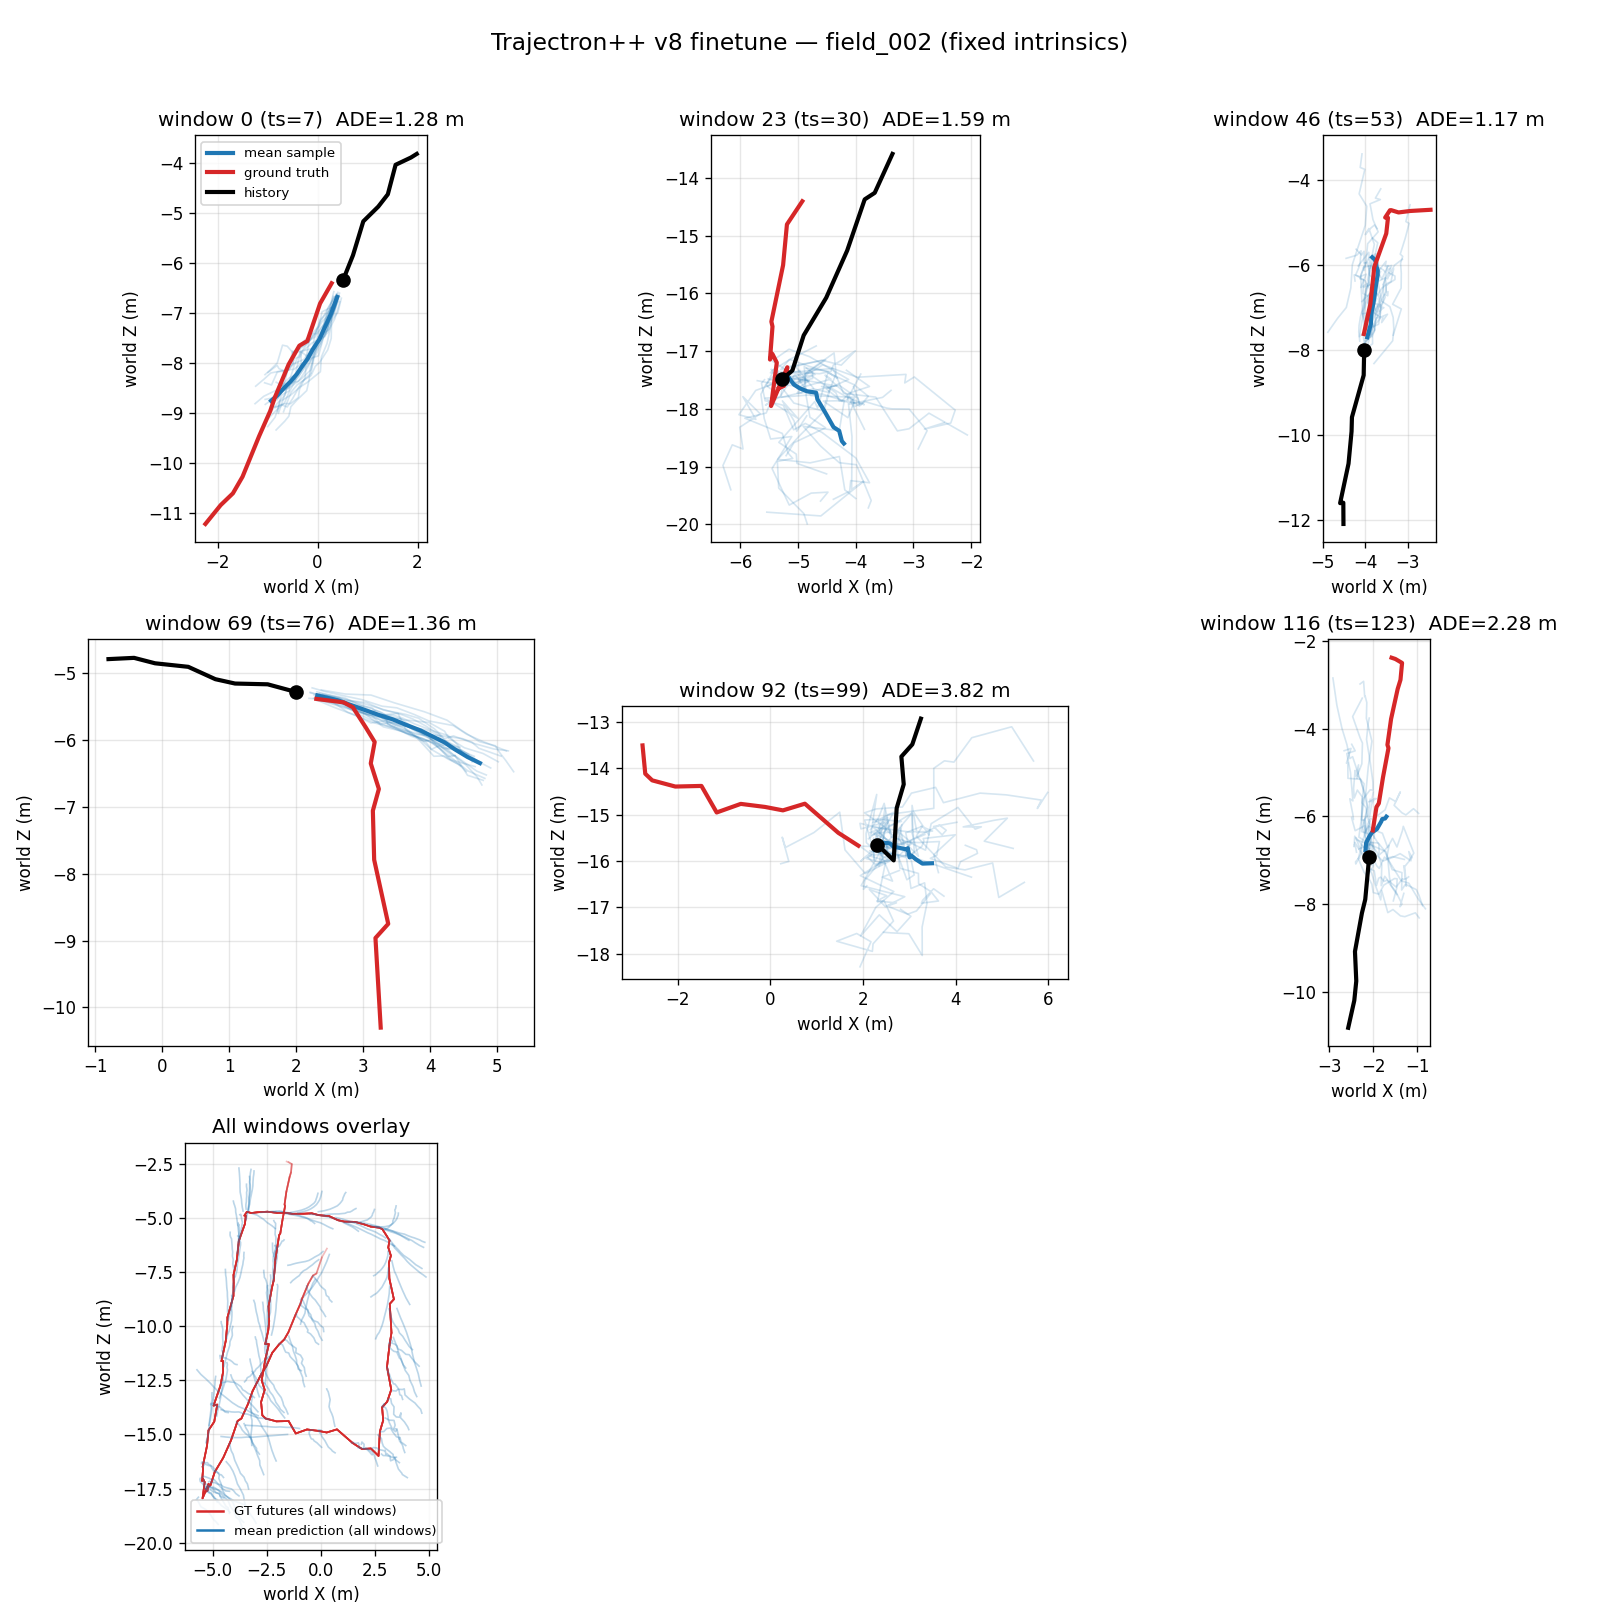

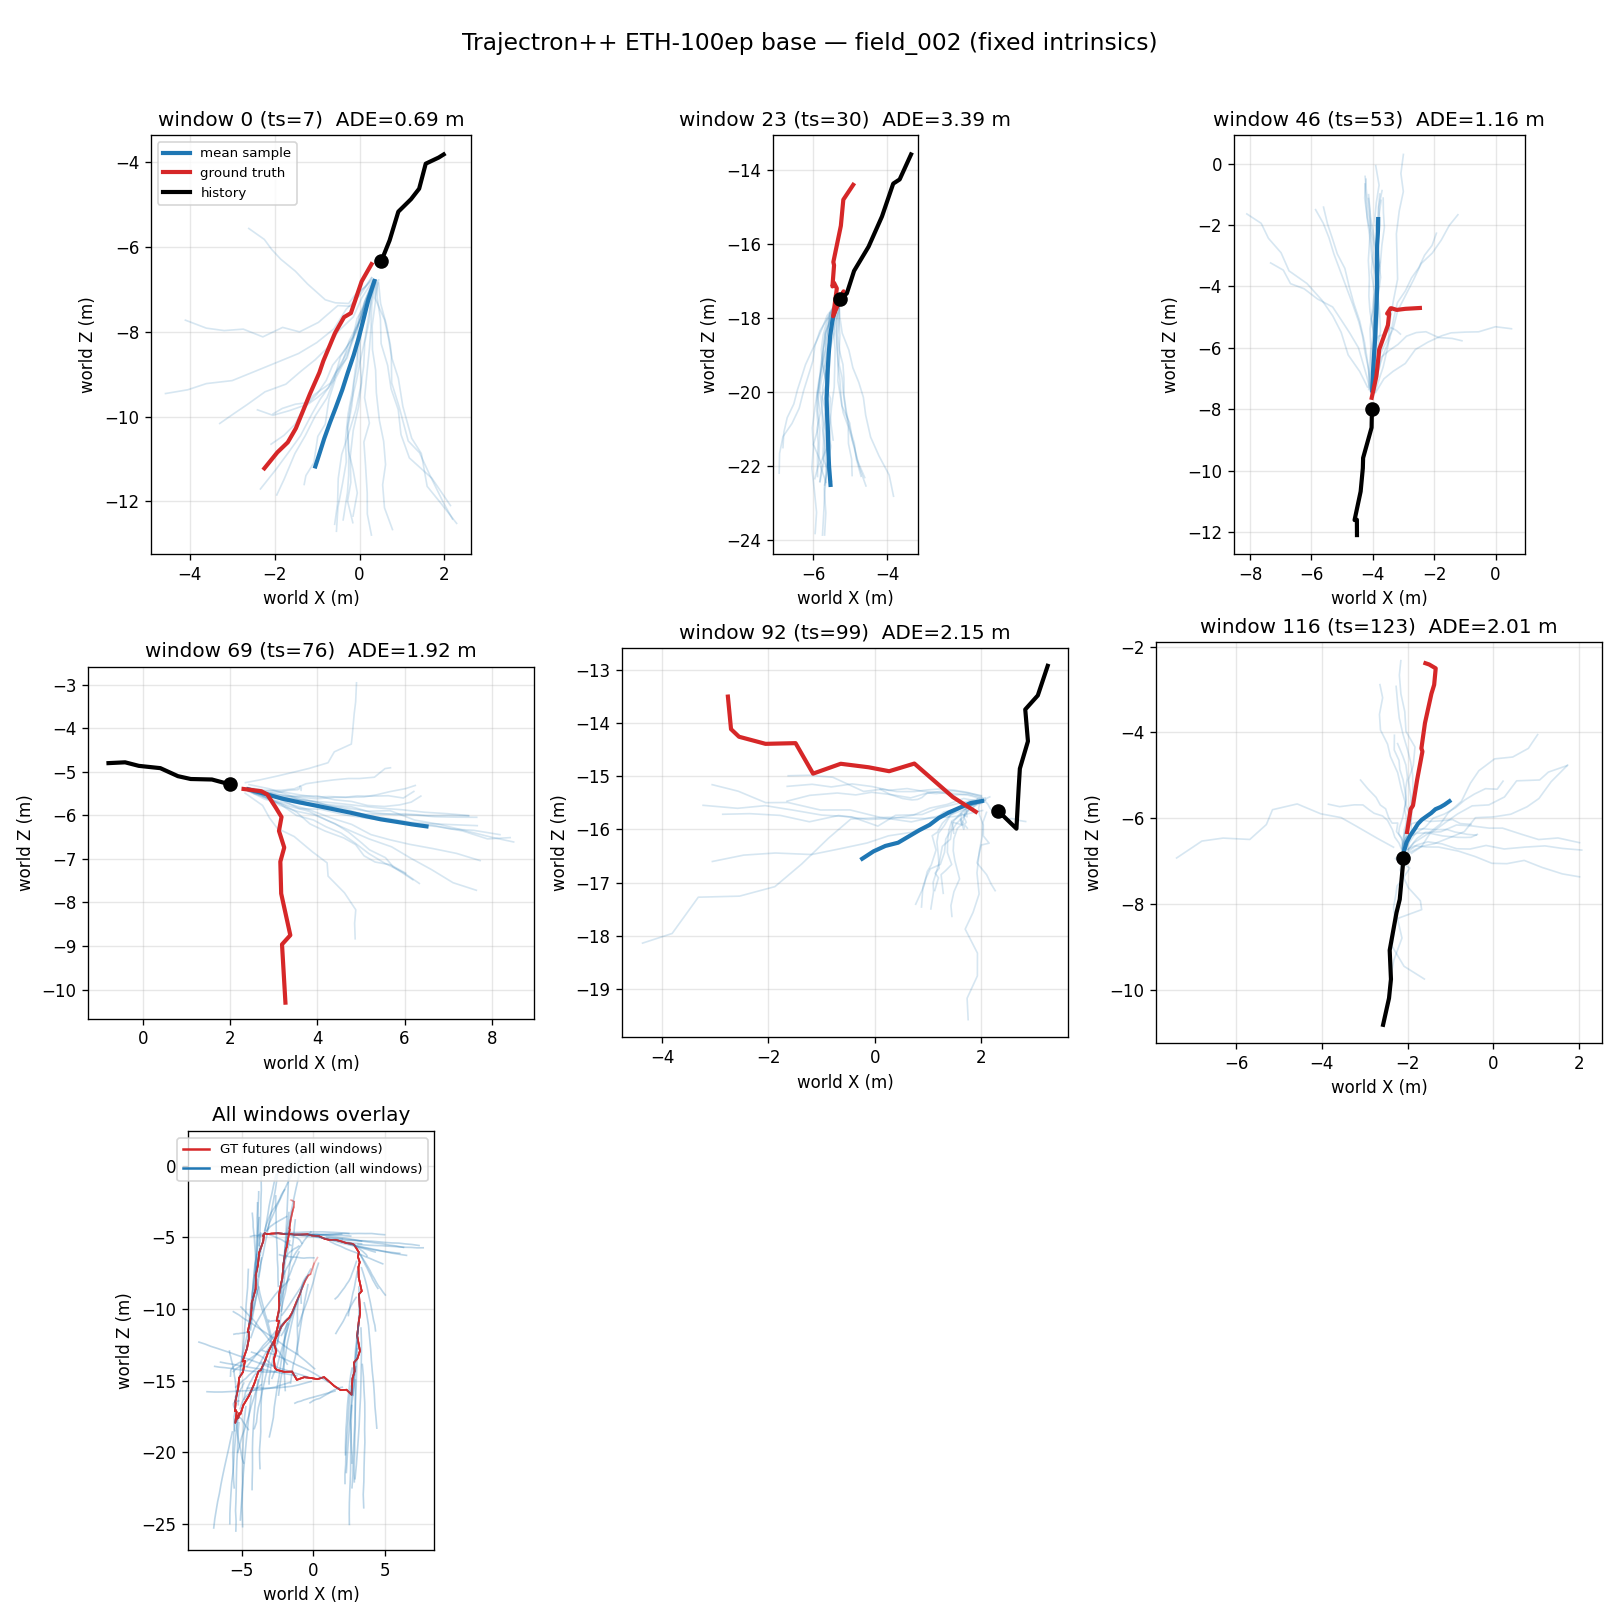

In [10]:
pred2 = np.load(PRED2)
pred2_eth = np.load(PRED2_ETH)

ade2, fde2, best2 = _npz_metrics(pred2)
ade2e, fde2e, best2e = _npz_metrics(pred2_eth)
print(f"Field 2 — windows: {pred2['history'].shape[0]}  "
      f"(H={pred2['history'].shape[1]}, F={pred2['future_gt'].shape[1]}, S={pred2['samples'].shape[1]})")
print("\n--- UAV fine-tuned v8 (ckpt 45) ---")
print(f"ADE (mean): {ade2:.3f} m   FDE: {fde2:.3f} m   best-of-20 ADE: {best2:.3f} m")
print("--- ETH base model (100 epochs, ckpt 100) ---")
print(f"ADE (mean): {ade2e:.3f} m   FDE: {fde2e:.3f} m   best-of-20 ADE: {best2e:.3f} m")

from IPython.display import Image as IPImage, display as IPdisplay
IPdisplay(IPImage(filename=str(FIELD2 / 'predictions_plot_v8.png')))
IPdisplay(IPImage(filename=str(FIELD2 / 'predictions_plot_eth100.png')))


---
## 4. Cross-clip comparison

Both clips were filmed in the same 10 m × 20 m court with the same static camera. After the intrinsics fix, the two trajectories live in almost the same volume:

- Field 1 — depth ≈ 1.4 – 16.8 m, walk width ≈ 9.7 m, mean speed ≈ 1.0 m/s.
- Field 2 — depth ≈ 2.4 – 18.2 m, walk width ≈ 9.0 m, mean speed ≈ 1.3 m/s.

ADE / FDE numbers are close across the two clips and across the two models. The fine-tuned v8 model and the ETH-100ep base model trade wins by clip — with only two clips that's expected; we'll need more recordings before we can claim a model-level ranking.

The "Field 2 is in a far-depth regime" interpretation in the previous version of this notebook was an **artefact of an FOV-unit bug** in `vio/pixel_to_world.py`. That bug was fixed for this run; both clips now sit inside the volleyball-court footprint as expected.

In [11]:
comparison = pd.DataFrame([
    {
        'clip': 'Field 1',
        'depth Z range (m)': f"[{sum1['z_min']:.1f}, {sum1['z_max']:.1f}]",
        'walk width X (m)': f"{sum1['x_max']-sum1['x_min']:.1f}",
        'v8 ADE': ade,    'v8 FDE': fde,    'v8 best-20': best_ade,
        'ETH ADE': ade_e, 'ETH FDE': fde_e, 'ETH best-20': best_e,
    },
    {
        'clip': 'Field 2',
        'depth Z range (m)': f"[{sum2['z_min']:.1f}, {sum2['z_max']:.1f}]",
        'walk width X (m)': f"{sum2['x_max']-sum2['x_min']:.1f}",
        'v8 ADE': ade2,    'v8 FDE': fde2,    'v8 best-20': best2,
        'ETH ADE': ade2e,  'ETH FDE': fde2e,  'ETH best-20': best2e,
    },
])

display(comparison.style.format({
    'v8 ADE': '{:.2f}', 'v8 FDE': '{:.2f}', 'v8 best-20': '{:.2f}',
    'ETH ADE': '{:.2f}', 'ETH FDE': '{:.2f}', 'ETH best-20': '{:.2f}',
}))


,clip,depth Z range (m),walk width X (m),v8 ADE,v8 FDE,v8 best-20,ETH ADE,ETH FDE,ETH best-20
0,Field 1,"[-16.8, -1.4]",9.7,2.12,3.70,1.55,2.24,4.03,1.46
1,Field 2,"[-18.2, -2.4]",9.0,2.43,4.59,1.75,2.05,4.14,1.33


---
## 5. Findings and next actions

### What works well

1. **VIO metric scale is reliable** for walking distances (1.5% and 0.4% errors at 5 m and 10 m respectively).
2. **End-to-end pipeline is functional**: YOLO foot point → ray-cast → world trajectory → Trajectron++ inference.
3. **Pipeline is repeatable across two clips** in the same court; trajectory bounds, walk width and depth match between Field 1 and Field 2.
4. **Both Trajectron++ models (v8 fine-tune and ETH-100ep base) run on the VIO output** without any retraining, and produce per-window ADE/FDE/best-of-20 metrics.

### What changed in this run

- Fixed an FOV-unit bug in `vio/pixel_to_world.py`. CamTrackAR's `FOV` column is in **radians**, but the previous code treated it as **degrees** and went through `math.radians()` again, which inflated the effective focal length by ~50× and made far ray-casts hit the floor 4-5× too far.
- The fixed pipeline now prefers `CameraKeyframes.CSV`'s `LensZoom` column (focal length in pixels, no unit ambiguity), falling back to `FOV` (radians) if `LensZoom` is missing.

### Limitations of this pilot

- **Only one camera position** (volleyball-court baseline). Need recordings from different viewpoints to test ray-cast generalisation.
- **Foot point ≠ contact point** in side views — when the lower body is occluded, the bottom-of-bbox foot-point biases the ray-cast slightly. Adding ankle keypoints from MediaPipe / pose detector would tighten this.
- **Smoothing window (31 frames, ≈ 0.5 s) is conservative**; for short reactive motions a smaller window would preserve more detail. The current choice is tuned to remove ray-cast outliers, not to maximise prediction quality.

### Immediate next actions

1. Record more clips (different camera placements, multiple people).
2. Add tracking (ByteTrack / BoT-SORT) so multi-person scenes work end-to-end.
3. Run the same Trajectron++ comparison on the homography pilot (notebook 02) to see how VIO ↔ homography rank the same models.

---
## 6. YOLO overlay videos (for visual verification)

The two overlay videos rendered from `foot_pixels.csv` (no YOLO re-run needed) are:

- `data/vio/field_001/overlay_from_csv.mp4`
- `data/vio/field_002/overlay_from_csv.mp4`

These let you visually confirm that bounding boxes and foot points are stable before ray-casting; user-verified ✓.

---
## Reproducibility commands

```bash
# Pixel -> world ray-cast (uses LensZoom from CameraKeyframes.CSV automatically)
python -m vio.pixel_to_world \
  --camera-csv data/vio/field_001/CameraKeyframes.CSV \
  --pixels-csv data/vio/field_001/foot_pixels.csv \
  --video-width 1920 --video-height 1440 \
  --output     data/vio/field_001/world_trajectory.csv

# Trajectron++ inference (UAV fine-tuned)
python -m vio.predict_with_trajectron \
  --trajectory data/vio/field_001/world_trajectory.csv \
  --model-dir ~/Trajectron-plus-plus/experiments/pedestrians/models/models_10_Mar_2026_00_42_50_uav_ft_v8_persp \
  --checkpoint 45 \
  --output    data/vio/field_001/predictions_v8.npz \
  --num-samples 20 --stride 1

# Trajectron++ inference (ETH 100-epoch base)
python -m vio.predict_with_trajectron \
  --trajectory data/vio/field_001/world_trajectory.csv \
  --model-dir ~/Trajectron-plus-plus/experiments/pedestrians/models/models_08_Mar_2026_23_54_27_eth_100ep \
  --checkpoint 100 \
  --output    data/vio/field_001/predictions_eth100.npz \
  --num-samples 20 --stride 1

# Render overlay video from existing YOLO CSV (no re-detection)
python -m vio.render_overlay_from_csv \
  --video  ~/Desktop/uav_perception/vio_raw_video/2026_05_18_1455591630/2026_05_18_1455591630.mp4 \
  --csv    data/vio/field_001/foot_pixels.csv \
  --output data/vio/field_001/overlay_from_csv.mp4
```


In [12]:
from IPython.display import Video, display

print('Field 1 YOLO overlay:')
display(Video(str(FIELD1 / 'overlay_from_csv.mp4'), embed=False))

print('Field 2 YOLO overlay:')
display(Video(str(FIELD2 / 'overlay_from_csv.mp4'), embed=False))

Field 1 YOLO overlay:


Field 2 YOLO overlay:
